# Project Proposal #1 — Performance Analysis

This notebook presents the experimental workflow for Project Proposal #1 of the Large Scale Data course.

The project evaluates the performance of different Python data-processing libraries when executing dataframe-style operations and a complete machine learning pipeline.

The main objectives are:

1. Compare execution times across different backends.
2. Identify performance bottlenecks in dataframe operations.
3. Evaluate syntactic and practical differences between libraries.
4. Build a machine learning pipeline to predict `fare_amount`.
5. Analyze both predictive quality and computational cost.

## 1. Generate or point to datasets
Start with a small taxi slice (for example, one month), then scale up by changing the input paths in the config.

In [1]:
import sys
print(sys.executable)

c:\Users\serpa\Documents\cdle\cdle-project\.venv\Scripts\python.exe


In [2]:
from pathlib import Path
import sys
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import project_proposal_1 as proposal

data_dir = PROJECT_ROOT / "data"
data_dir.mkdir(exist_ok=True)

proposal.generate_synthetic_taxi_data(data_dir / "taxi_small.csv", rows=200, seed=1)
proposal.generate_synthetic_taxi_data(data_dir / "taxi_reference.csv", rows=500, seed=2)
proposal.generate_synthetic_taxi_data(data_dir / "taxi_large.csv", rows=800, seed=3)

print("Project root:", PROJECT_ROOT)
print("Synthetic datasets generated in:", data_dir)

Project root: C:\Users\serpa\Documents\cdle\cdle-project
Synthetic datasets generated in: C:\Users\serpa\Documents\cdle\cdle-project\data


## 2. Configure the benchmark libraries
Use `MODIN_ENGINE=dask` to evaluate Dask+Modin, add `dask_rapids` in GPU environments, and install `pyspark` if you want to include Koalas / pandas-on-Spark.

In [3]:
config = {
    'output_dir': '../outputs',
    'benchmark_backends': ['pandas', 'joblib', 'dask'],
    'benchmark_datasets': [
        {'name': 'small_sample', 'path': '../data/taxi_small.csv'},
        {'name': 'nyc_taxi_reference', 'path': '../data/taxi_reference.csv'},
        {'name': 'large_sample', 'path': '../data/taxi_large.csv'},
    ],
    'ml_dataset': {'name': 'nyc_taxi_reference', 'path': '../data/taxi_reference.csv'}
}
Path('../configs').mkdir(exist_ok=True)
config_path = Path('../configs/notebook_config.json')
config_path.write_text(json.dumps(config, indent=2), encoding='utf-8')
config_path


WindowsPath('../configs/notebook_config.json')

## 3. Run experiments and the ML pipeline
The benchmark summary table records execution time per operation and backend; the ML stage reports regression and classification metrics.

In [4]:
report_path = proposal.run_full_config(config_path)
report_path


WindowsPath('../outputs/project_proposal_1_report.md')

In [5]:
print(Path('../outputs/benchmark_summary.md').read_text(encoding='utf-8'))
print(Path('../outputs/ml_summary.md').read_text(encoding='utf-8'))
print(Path('../outputs/project_proposal_1_report.md').read_text(encoding='utf-8'))


| Dataset | Operation | dask | joblib | pandas |
| --- | --- | --- | --- | --- |
| large_sample | feature_engineering | n/a | 0.0000s | 0.0000s |
| large_sample | filter_rows | n/a | 0.0172s | 0.0002s |
| large_sample | groupby_aggregate | n/a | 0.0012s | 0.0010s |
| large_sample | join_lookup | n/a | 0.0009s | 0.0009s |
| large_sample | read_data | skipped: No module named 'pyarrow' | 0.0048s | 0.0141s |
| large_sample | sort_values | n/a | 0.0008s | 0.0009s |
| nyc_taxi_reference | feature_engineering | n/a | 0.0000s | 0.0000s |
| nyc_taxi_reference | filter_rows | n/a | 0.0176s | 0.0002s |
| nyc_taxi_reference | groupby_aggregate | n/a | 0.0011s | 0.0009s |
| nyc_taxi_reference | join_lookup | n/a | 0.0009s | 0.0008s |
| nyc_taxi_reference | read_data | skipped: No module named 'pyarrow' | 0.0046s | 0.0127s |
| nyc_taxi_reference | sort_values | n/a | 0.0007s | 0.0007s |
| small_sample | feature_engineering | n/a | 0.0000s | 0.0000s |
| small_sample | filter_rows | n/a | 1.2953s | 0

## 4. Machine Learning Results and Visualizations

This section focuses on the machine learning part of the project.

The objective is to evaluate the prediction of `fare_amount` using two approaches:

- Regression with `XGBRegressor`, where the target is the continuous fare amount.
- Classification with `LogisticRegression`, where `fare_amount` is discretized into quantile-based fare classes.

The analysis includes predictive metrics and computational performance metrics, specifically training time and prediction time.

In [6]:
ml_results_path = Path('../outputs/ml_results.json')

with ml_results_path.open('r', encoding='utf-8') as handle:
    ml_results_raw = json.load(handle)

ml_rows = []

for record in ml_results_raw:
    task = record['task']
    model = record['model']

    for metric_name, metric_value in record['metrics'].items():
        ml_rows.append(
            {
                'task': task,
                'model': model,
                'metric': metric_name,
                'value': metric_value,
            }
        )

ml_results = pd.DataFrame(ml_rows)

display(ml_results)

,task,model,metric,value
0,regression,XGBRegressor,rmse,1.888445
1,regression,XGBRegressor,mae,1.454619
2,regression,XGBRegressor,r2,0.987890
3,regression,XGBRegressor,training_time,4.635323
4,regression,XGBRegressor,prediction_time,0.007485
5,classification,LogisticRegression,accuracy,0.950000
6,classification,LogisticRegression,precision_weighted,0.951538
7,classification,LogisticRegression,recall_weighted,0.950000
8,classification,LogisticRegression,f1_weighted,0.950172
9,classification,LogisticRegression,precision_macro,0.951538


### 4.1 Regression metrics

The regression task is evaluated using RMSE, MAE and R².

- RMSE and MAE measure prediction error. Lower values are better.
- R² measures the proportion of variance explained by the model. Higher values are better.

,task,model,metric,value
0,regression,XGBRegressor,rmse,1.888445
1,regression,XGBRegressor,mae,1.454619
2,regression,XGBRegressor,r2,0.987890


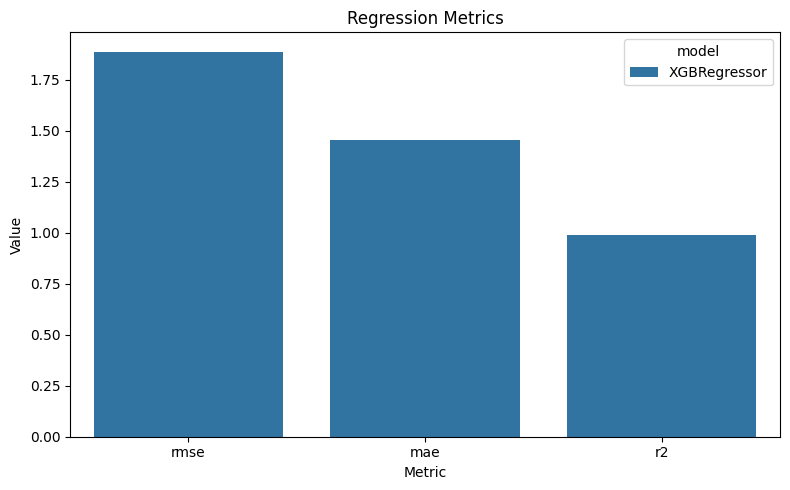

Saved figure: ..\outputs\figures\regression_metrics.png


In [7]:
figures_dir = Path('../outputs/figures')
figures_dir.mkdir(exist_ok=True)

regression_metrics = ml_results[
    (ml_results['task'] == 'regression') &
    (ml_results['metric'].isin(['rmse', 'mae', 'r2']))
].copy()

display(regression_metrics)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=regression_metrics,
    x='metric',
    y='value',
    hue='model'
)

plt.xlabel('Metric')
plt.ylabel('Value')
plt.title('Regression Metrics')
plt.tight_layout()

figure_path = figures_dir / 'regression_metrics.png'
plt.savefig(figure_path, dpi=300)
plt.show()

print('Saved figure:', figure_path)

### 4.2 Classification metrics

The classification task evaluates the discretized version of `fare_amount`.

Weighted metrics account for class frequency, while macro metrics give the same importance to all classes. Reporting both provides a more complete evaluation of the classifier.

,task,model,metric,value
5,classification,LogisticRegression,accuracy,0.950000
6,classification,LogisticRegression,precision_weighted,0.951538
7,classification,LogisticRegression,recall_weighted,0.950000
8,classification,LogisticRegression,f1_weighted,0.950172
9,classification,LogisticRegression,precision_macro,0.951538
10,classification,LogisticRegression,recall_macro,0.950000
11,classification,LogisticRegression,f1_macro,0.950172


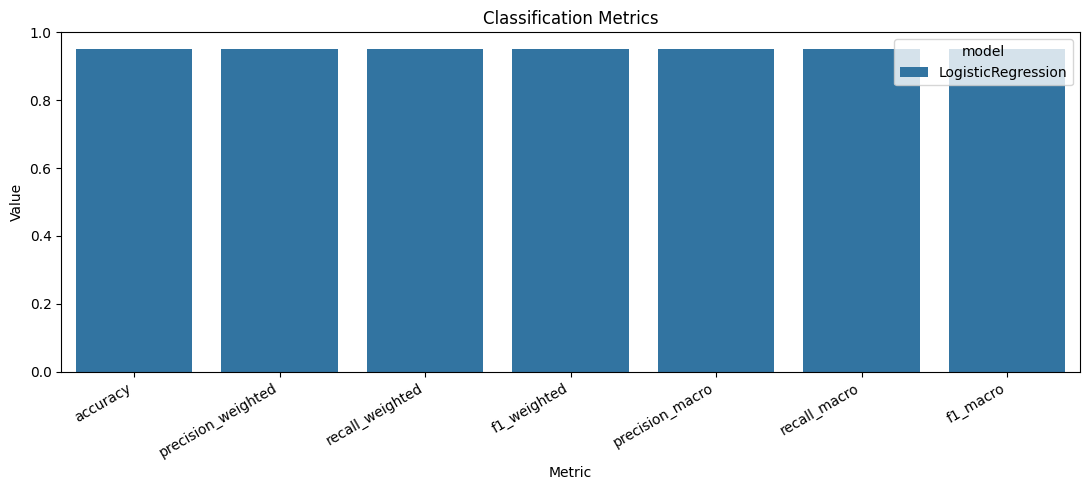

Saved figure: ..\outputs\figures\classification_metrics.png


In [8]:
classification_metrics = ml_results[
    (ml_results['task'] == 'classification') &
    (ml_results['metric'].isin([
        'accuracy',
        'precision_weighted',
        'recall_weighted',
        'f1_weighted',
        'precision_macro',
        'recall_macro',
        'f1_macro',
    ]))
].copy()

display(classification_metrics)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=classification_metrics,
    x='metric',
    y='value',
    hue='model'
)

plt.xlabel('Metric')
plt.ylabel('Value')
plt.title('Classification Metrics')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

figure_path = figures_dir / 'classification_metrics.png'
plt.savefig(figure_path, dpi=300)
plt.show()

print('Saved figure:', figure_path)

### 4.3 ML execution time

Since this is a performance analysis project, the ML pipeline also reports training and prediction time.

Training time includes preprocessing, cross-validation, hyperparameter tuning and model fitting. Prediction time measures the cost of generating predictions on the test set.

,task,model,metric,value
3,regression,XGBRegressor,training_time,4.635323
4,regression,XGBRegressor,prediction_time,0.007485
12,classification,LogisticRegression,training_time,0.165167
13,classification,LogisticRegression,prediction_time,0.006292


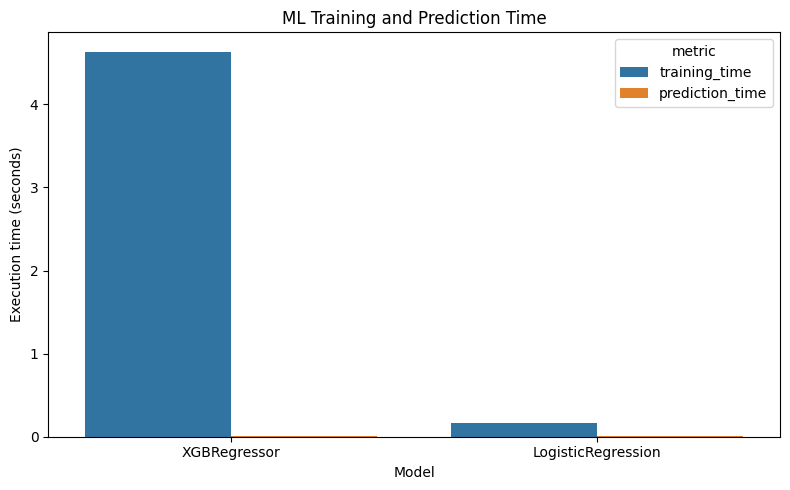

Saved figure: ..\outputs\figures\ml_training_prediction_time.png


In [9]:
ml_time_metrics = ml_results[
    ml_results['metric'].isin(['training_time', 'prediction_time'])
].copy()

display(ml_time_metrics)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=ml_time_metrics,
    x='model',
    y='value',
    hue='metric'
)

plt.xlabel('Model')
plt.ylabel('Execution time (seconds)')
plt.title('ML Training and Prediction Time')
plt.tight_layout()

figure_path = figures_dir / 'ml_training_prediction_time.png'
plt.savefig(figure_path, dpi=300)
plt.show()

print('Saved figure:', figure_path)

### 4.4 Confusion matrix

The confusion matrix shows how the predicted fare classes compare with the true fare classes.

Rows represent the actual classes and columns represent the predicted classes. Values on the diagonal correspond to correct predictions.

,0,1,2,3
0,24,1,0,0
1,1,24,0,0
2,0,1,24,0
3,0,0,2,23


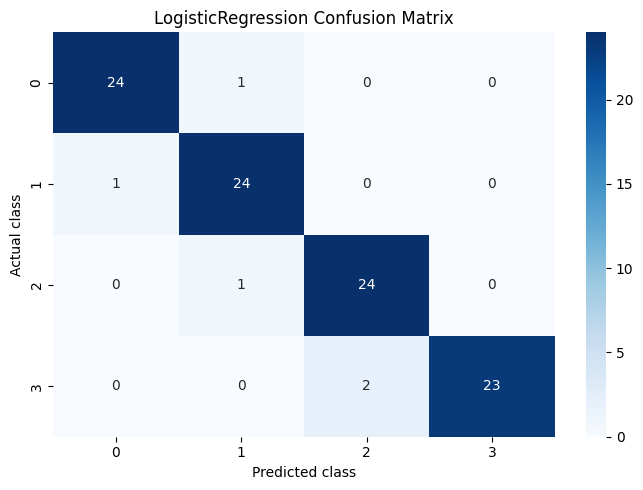

Saved figure: ..\outputs\figures\classification_confusion_matrix.png


In [10]:
classification_record = next(
    record for record in ml_results_raw
    if record['task'] == 'classification'
)

confusion_matrix_values = classification_record['confusion_matrix']

confusion_matrix_df = pd.DataFrame(confusion_matrix_values)

display(confusion_matrix_df)

plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.title('LogisticRegression Confusion Matrix')
plt.tight_layout()

figure_path = figures_dir / 'classification_confusion_matrix.png'
plt.savefig(figure_path, dpi=300)
plt.show()

print('Saved figure:', figure_path)

### 4.5 ML discussion

The ML pipeline evaluates both predictive quality and computational cost.

The regression task predicts the continuous value of `fare_amount`, while the classification task predicts quantile-based fare classes. This allows the project to compare two different predictive formulations.

The inclusion of training and prediction times is important because a model with strong predictive performance may also require higher computational cost. Therefore, the ML models should be compared not only by prediction metrics, but also by execution time.